In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=adf3c227d0c43ec3df0e370cfa9ad946f264061ebf38633254a4753abdd56d9c
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


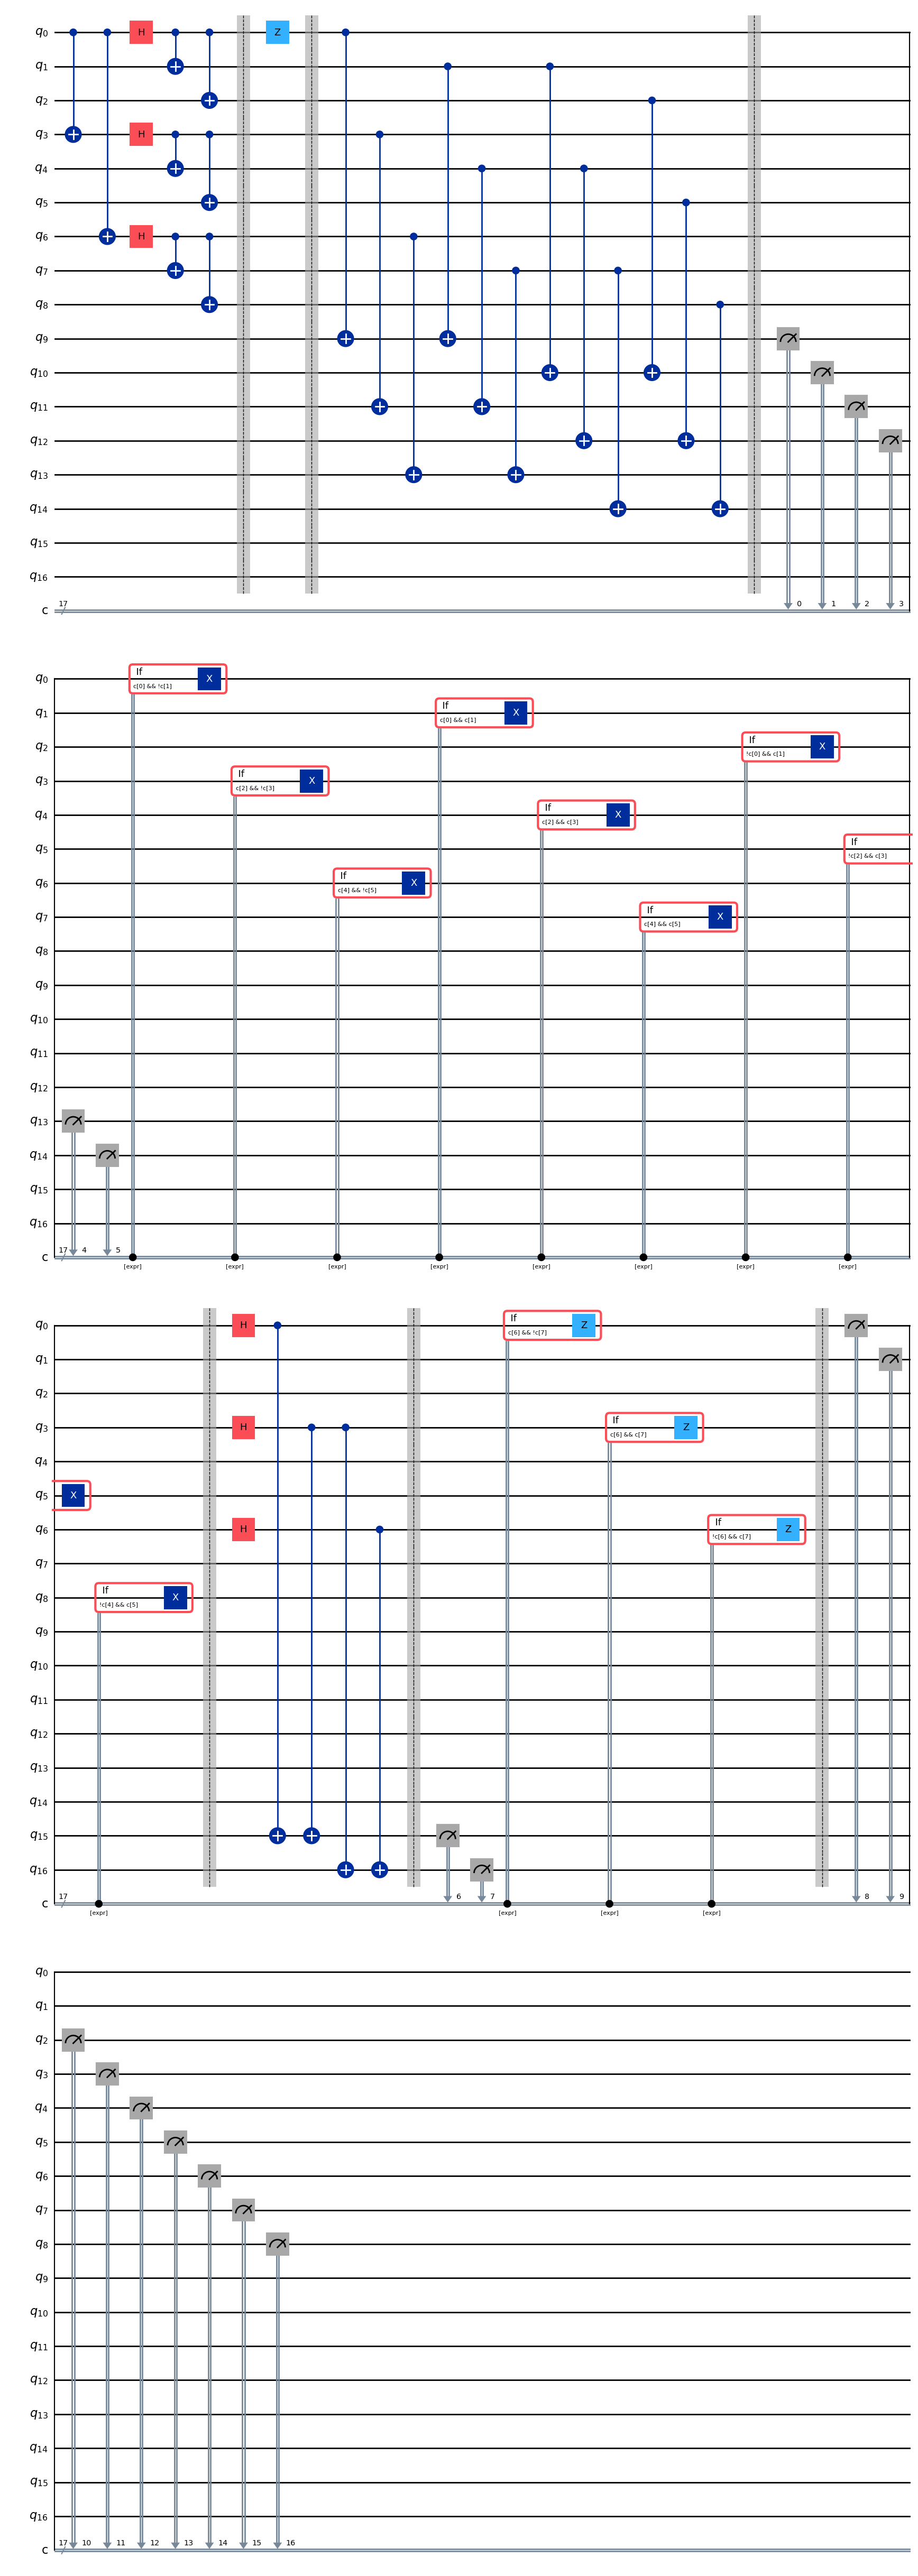

In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.

shor = QuantumCircuit(17, 17)

shor.cx(0, 3)
shor.cx(0, 6)
shor.h(0)
shor.h(3)
shor.h(6)
shor.cx(0, 1);  shor.cx(0, 2)
shor.cx(3, 4);  shor.cx(3, 5)
shor.cx(6, 7);  shor.cx(6, 8)
shor.barrier()

shor.z(0)
shor.barrier()

shor.cx(0,9);  shor.cx(1,9)
shor.cx(1,10); shor.cx(2,10)
shor.cx(3,11); shor.cx(4,11)
shor.cx(4,12); shor.cx(5,12)
shor.cx(6,13); shor.cx(7,13)
shor.cx(7,14); shor.cx(8,14)
shor.barrier()

shor.measure([9,10,11,12,13,14], [0,1,2,3,4,5])

with shor.if_test(expr.logic_and(shor.clbits[0], expr.logic_not(shor.clbits[1]))): shor.x(0)
with shor.if_test(expr.logic_and(shor.clbits[0], shor.clbits[1])): shor.x(1)
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[0]), shor.clbits[1])): shor.x(2)

with shor.if_test(expr.logic_and(shor.clbits[2], expr.logic_not(shor.clbits[3]))): shor.x(3)
with shor.if_test(expr.logic_and(shor.clbits[2], shor.clbits[3])): shor.x(4)
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[2]), shor.clbits[3])): shor.x(5)

with shor.if_test(expr.logic_and(shor.clbits[4], expr.logic_not(shor.clbits[5]))): shor.x(6)
with shor.if_test(expr.logic_and(shor.clbits[4], shor.clbits[5])): shor.x(7)
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[4]), shor.clbits[5])): shor.x(8)
shor.barrier()

shor.h(0); shor.h(3); shor.h(6)

shor.cx(0,15); shor.cx(3,15)
shor.cx(3,16); shor.cx(6,16)
shor.barrier()

shor.measure([15,16], [6,7])

with shor.if_test(expr.logic_and(shor.clbits[6], expr.logic_not(shor.clbits[7]))): shor.z(0)
with shor.if_test(expr.logic_and(shor.clbits[6], shor.clbits[7])): shor.z(3)
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[6]), shor.clbits[7])): shor.z(6)
shor.barrier()

shor.measure([0,1,2,3,4,5,6,7,8], [8,9,10,11,12,13,14,15,16])
shor.draw("mpl")

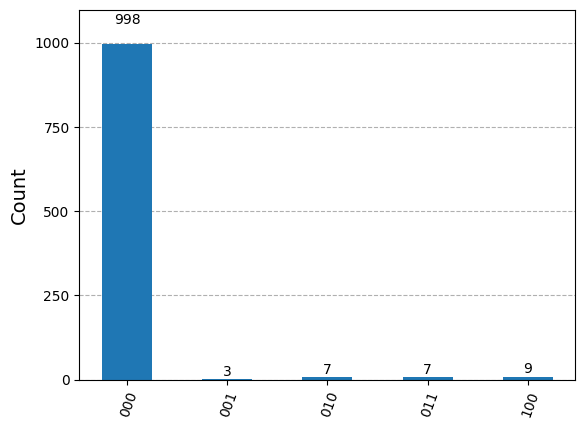

In [5]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=17, control_flow=True)
compiled = transpile(shor, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts, indices=[2,3,4])
plot_histogram(mcounts)